# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan


- Nama: Muchammad Wildan Alkautsar
- Email:muchammadwr@gmail.com
- Id Dicoding: @muchammadwr


## Persiapan


### Menyiapkan library yang dibutuhkan


In [1]:
import pandas as pd  
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
import pickle  

from sklearn.preprocessing import LabelEncoder  
from sklearn.model_selection import train_test_split  
from sklearn.pipeline import Pipeline  
from sklearn.compose import ColumnTransformer  
from sklearn.impute import SimpleImputer  
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder  
from sklearn.ensemble import RandomForestClassifier  
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix  
from sklearn.utils import resample  

### Menyiapkan data yang akan diguankan


## Data Understanding


In [2]:
df = pd.read_csv('data/data.csv', delimiter=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.iloc[:, :len(df.columns)//2].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Marital_status                4424 non-null   int64  
 1   Application_mode              4424 non-null   int64  
 2   Application_order             4424 non-null   int64  
 3   Course                        4424 non-null   int64  
 4   Daytime_evening_attendance    4424 non-null   int64  
 5   Previous_qualification        4424 non-null   int64  
 6   Previous_qualification_grade  4424 non-null   float64
 7   Nacionality                   4424 non-null   int64  
 8   Mothers_qualification         4424 non-null   int64  
 9   Fathers_qualification         4424 non-null   int64  
 10  Mothers_occupation            4424 non-null   int64  
 11  Fathers_occupation            4424 non-null   int64  
 12  Admission_grade               4424 non-null   float64
 13  Dis

In [4]:
df.iloc[:, len(df.columns) //2:].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 19 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Scholarship_holder                            4424 non-null   int64  
 1   Age_at_enrollment                             4424 non-null   int64  
 2   International                                 4424 non-null   int64  
 3   Curricular_units_1st_sem_credited             4424 non-null   int64  
 4   Curricular_units_1st_sem_enrolled             4424 non-null   int64  
 5   Curricular_units_1st_sem_evaluations          4424 non-null   int64  
 6   Curricular_units_1st_sem_approved             4424 non-null   int64  
 7   Curricular_units_1st_sem_grade                4424 non-null   float64
 8   Curricular_units_1st_sem_without_evaluations  4424 non-null   int64  
 9   Curricular_units_2nd_sem_credited             4424 non-null   i

## Data Preparation / Preprocessing


In [5]:
df.isnull().sum()

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


In [6]:
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {jumlah_duplikat}")

Jumlah baris duplikat: 0


## Exploratory Data Analysis


### Percentage of Student Status


In [7]:
status_percentage = df['Status'].value_counts(normalize=True) * 100
status_percentage.round(2)

Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64

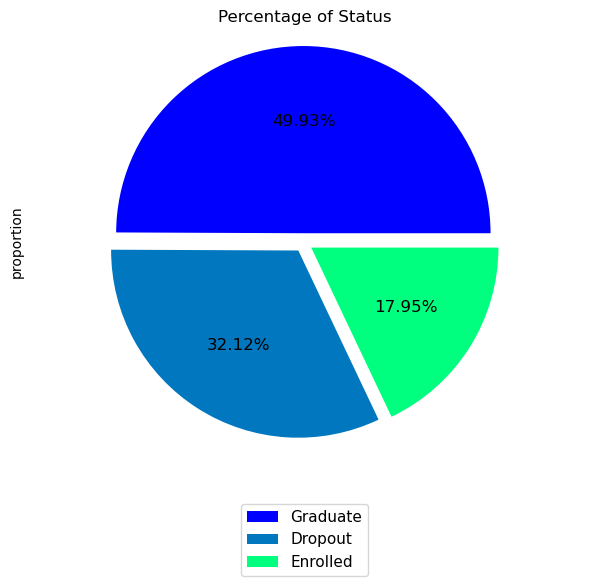

In [8]:
colors = ['#0000FF', '#0077BE', '#00FF7F']
status_percentage.plot.pie(
    labels=None,  
    autopct="%.2f%%",
    fontsize=12,
    figsize=(6, 6),
    colors=colors,
    explode = [0.05] * len(status_percentage)

)
plt.title("Percentage of Status")
plt.legend(
    labels=status_percentage.index,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    fontsize=11,
    title_fontsize=12
)

plt.axis('equal')  
plt.tight_layout()
plt.show()

#### Status by Marital Status


In [9]:
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [10]:
marital_status_category = {
    1 : "single", 2 : "married",  3 : "widower", 4 : "divorced",  5 : "facto union" ,6 :"legally separated"
}

df['MaritalStatusCategory'] = df['Marital_status'].map(marital_status_category)

status_by_marital_status = pd.pivot_table(
    df,
    values="Marital_status",
    index="MaritalStatusCategory",
    columns="Status",
    aggfunc="count"
)

status_by_marital_status

Status,Dropout,Enrolled,Graduate
MaritalStatusCategory,,,
divorced,42,16,33
facto union,11,3,11
legally separated,4,1,1
married,179,52,148
single,1184,720,2015
widower,1,2,1


Distribusi mahasiswa berdasarkan status pernikahan menunjukkan bahwa kelompok dengan status single mendominasi jumlah keseluruhan, dengan tingkat kelulusan tertinggi (2.015) meskipun juga mencatat angka dropout yang cukup besar (1.184), yang dapat mencerminkan kombinasi antara jumlah populasi yang besar dan keberagaman dalam kesiapan akademik. Kelompok married dan divorced menunjukkan angka dropout yang signifikan (masing-masing 179 dan 42), yang kemungkinan berkaitan dengan beban tanggung jawab keluarga atau dampak emosional dari perubahan status rumah tangga. Menariknya, kelompok facto union memiliki jumlah kelulusan yang setara dengan dropout meskipun populasinya kecil, menunjukkan bahwa hubungan informal tidak selalu berdampak negatif terhadap capaian akademik. Sementara itu, kelompok legally separated dan widower memiliki jumlah data yang sangat kecil namun tetap menunjukkan keberhasilan studi pada sebagian individu, menandakan adanya ketahanan akademik meskipun dalam kondisi keluarga yang tidak stabil.


#### Status by Daytime/evening attendance


In [11]:
daytime_evening_attendance_categorical = {
    1: "DayTime",
    0: "Evening"
}
df['DaytimeEveningAttendance'] = df['Daytime_evening_attendance'].map(daytime_evening_attendance_categorical)
df['DaytimeEveningAttendance']

0       DayTime
1       DayTime
2       DayTime
3       DayTime
4       Evening
         ...   
4419    DayTime
4420    DayTime
4421    DayTime
4422    DayTime
4423    DayTime
Name: DaytimeEveningAttendance, Length: 4424, dtype: object

In [12]:
daytime_evening_attendance = pd.pivot_table(
    df,
    values="Daytime_evening_attendance",
    index="DaytimeEveningAttendance",
    columns="Status",
    aggfunc="count"
)

daytime_evening_attendance

Status,Dropout,Enrolled,Graduate
DaytimeEveningAttendance,,,
DayTime,1214,719,2008
Evening,207,75,201


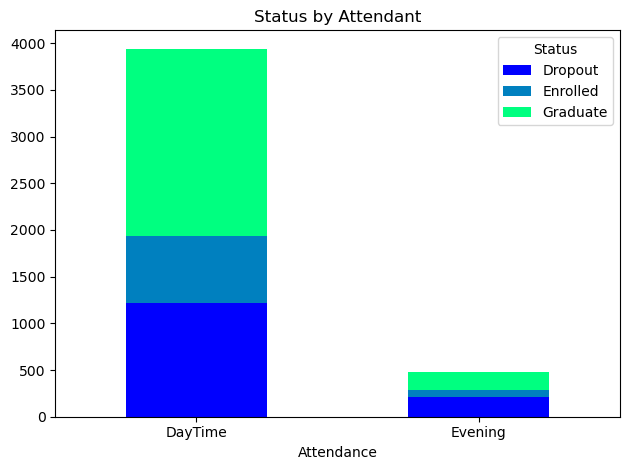

In [13]:
daytime_evening_attendance.plot(kind="bar", stacked=True, colormap='winter')
plt.title("Status by Attendant")
plt.xticks(rotation=0)
plt.xlabel("Attendance")
plt.tight_layout()
plt.show()

distribusi mahasiswa berdasarkan waktu kehadiran kuliah—daytime (siang/sore hari) dan evening (malam hari)—terhadap status akademik mereka: dropout, masih terdaftar (enrolled), dan lulus (graduate). Mayoritas mahasiswa mengikuti kelas pada waktu daytime, dengan jumlah dropout mencapai 1.214 orang, 719 masih aktif, dan 2.008 berhasil lulus. Sebaliknya, mahasiswa kelas malam (evening) memiliki jumlah yang jauh lebih kecil dengan 207 dropout, 75 masih aktif, dan 201 yang telah lulus.


#### Status by Qualification Grade


In [14]:
status_by_avg_qualification_grade = pd.pivot_table(
    df,
    values="Previous_qualification_grade",
    index="Status",
    aggfunc="mean"
).round(2)
status_by_avg_qualification_grade

,Previous_qualification_grade
Status,
Dropout,131.11
Enrolled,131.21
Graduate,134.08


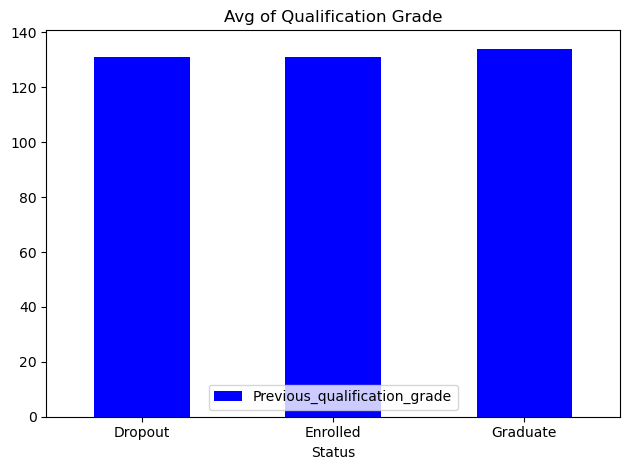

In [15]:
status_by_avg_qualification_grade.plot(kind="bar", colormap="winter")
plt.title("Avg of Qualification Grade")
plt.xticks(rotation=0)
plt.xlabel("Status")
plt.tight_layout()
plt.show()

rata-rata nilai kualifikasi pendidikan sebelumnya (previous qualification grade) berdasarkan status akademik mahasiswa, yaitu Dropout, Enrolled, dan Graduate. Mahasiswa yang berhasil menyelesaikan studinya (Graduate) memiliki rata-rata nilai tertinggi sebesar 134.08, diikuti oleh mahasiswa yang masih aktif (Enrolled) dengan nilai rata-rata 131.21, dan mahasiswa yang mengalami putus studi (Dropout) memiliki nilai terendah yaitu 131.11


#### Status by Admission Grade


In [16]:
status_by_avg_admission_grade = pd.pivot_table(
    df,
    values="Admission_grade",
    index="Status",
    aggfunc="mean"
).round(2)

status_by_avg_admission_grade

,Admission_grade
Status,
Dropout,124.96
Enrolled,125.53
Graduate,128.79


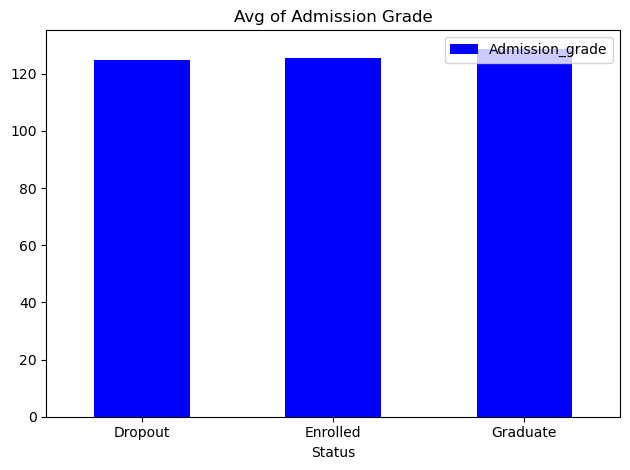

In [17]:
status_by_avg_admission_grade.plot(kind="bar", colormap="winter")
plt.title("Avg of Admission Grade")
plt.xticks(rotation=0)
plt.xlabel("Status")
plt.tight_layout()
plt.show()

Rata-rata nilai admission grade mahasiswa menunjukkan pola yang konsisten terhadap status akademik. Mahasiswa yang lulus memiliki nilai rata-rata tertinggi (**128.79**), diikuti oleh mahasiswa yang masih terdaftar (**125.53**), sementara mahasiswa yang dropout mencatat nilai terendah (**124.96**). Hal ini mengindikasikan bahwa semakin tinggi skor seleksi masuk, semakin besar kemungkinan mahasiswa untuk menyelesaikan studinya.


#### Status by Displaced


In [18]:
displaced_category = {
    0: "No",
    1: "Yes"
}
df['DisplacedCategory'] = df['Displaced'].map(displaced_category)

In [19]:
status_by_displaced = pd.pivot_table(
    df,
    values="Displaced",
    index="DisplacedCategory",
    columns="Status",
    aggfunc="count"
)
status_by_displaced

Status,Dropout,Enrolled,Graduate
DisplacedCategory,,,
No,752,361,885
Yes,669,433,1324


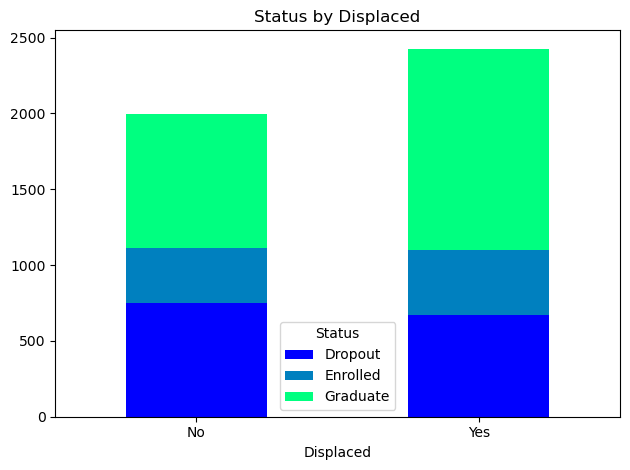

In [20]:
status_by_displaced.plot(kind="bar", stacked=True, colormap='winter')
plt.title("Status by Displaced")
plt.xticks(rotation=0)
plt.xlabel("Displaced")
plt.tight_layout()
plt.show()

Status akademik mahasiswa berdasarkan kategori _displaced person_. Menariknya, mahasiswa dengan status "Yes" (displaced) memiliki angka kelulusan yang lebih tinggi (**1.324**) dibandingkan dengan yang "No" (**885**), meskipun jumlah dropout juga cukup besar (**669**). Sebaliknya, mahasiswa non-displaced memiliki jumlah dropout lebih tinggi (**752**) dan jumlah mahasiswa aktif lebih rendah (**361** vs **433**). Temuan ini mengindikasikan bahwa mahasiswa yang berasal dari kelompok terdampak perpindahan justru menunjukkan tingkat penyelesaian studi yang relatif baik, yang dapat mencerminkan tingkat motivasi atau dukungan institusional yang lebih kuat pada kelompok ini.


#### Status by Educational Special


In [21]:
df['EducationalSpecialNeedsCategory'] = df['Educational_special_needs'].map({0: "No", 1: "Yes"})
status_by_educational_special = pd.pivot_table(
    df,
    values="Educational_special_needs",
    index='EducationalSpecialNeedsCategory',
    columns="Status",
    aggfunc="count"
)
status_by_educational_special

Status,Dropout,Enrolled,Graduate
EducationalSpecialNeedsCategory,,,
No,1404,783,2186
Yes,17,11,23


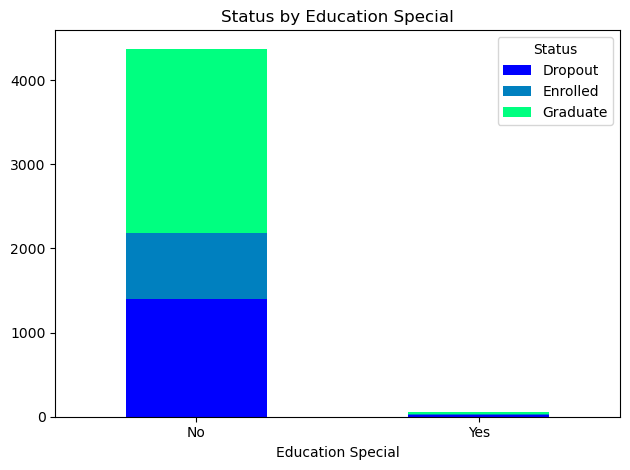

In [22]:
status_by_educational_special.plot(kind="bar", stacked=True, colormap='winter')
plt.title("Status by Education Special")
plt.xticks(rotation=0)
plt.xlabel("Education Special")
plt.tight_layout()
plt.show()

Status akademik mahasiswa berdasarkan apakah mereka memiliki kebutuhan pendidikan khusus (_Special Educational Needs_). Dari total populasi, mahasiswa tanpa kebutuhan khusus mendominasi dengan jumlah kelulusan sebanyak **2.186**, dropout **1.404**, dan mahasiswa aktif **783**. Sementara itu, mahasiswa dengan kebutuhan khusus menunjukkan jumlah yang jauh lebih kecil secara absolut, yaitu **23** lulus, **17** dropout, dan **11** masih aktif. Meskipun kelompok dengan kebutuhan khusus jumlahnya kecil, rasio kelulusan terhadap totalnya cukup signifikan, yang dapat mencerminkan keberhasilan implementasi pendekatan pendidikan inklusif atau dukungan akademik khusus bagi kelompok ini.


#### Status by Debtor


In [23]:
df['DebtorCategory'] = df['Debtor'].map({0: "No", 1:"Yes"})
status_by_debtor = pd.pivot_table(
    df,
    values="Debtor",
    index='DebtorCategory',
    columns="Status",
    aggfunc="count"
)
status_by_debtor

Status,Dropout,Enrolled,Graduate
DebtorCategory,,,
No,1109,704,2108
Yes,312,90,101


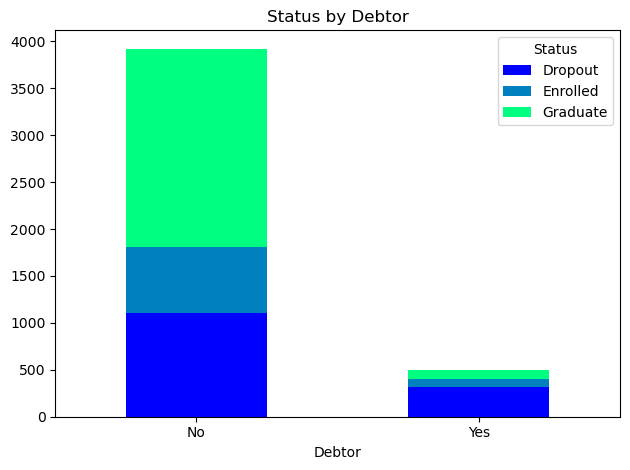

In [24]:
status_by_debtor.plot(kind="bar", stacked=True, colormap='winter')
plt.title("Status by Debtor")
plt.xticks(rotation=0)
plt.xlabel("Debtor")
plt.tight_layout()
plt.show()

status akademik mahasiswa berdasarkan status kewajiban finansial mereka terhadap institusi (DebtorCategory). Mahasiswa yang tidak memiliki utang (kategori "No") mendominasi dengan **2.108** lulusan, **1.109** dropout, dan **704** masih aktif. Sementara itu, mahasiswa yang berstatus sebagai debitur (kategori "Yes") mencatat **101** lulusan, **312** dropout, dan hanya **90** yang masih aktif. Rasio dropout yang tinggi pada kelompok debitur mengindikasikan bahwa beban finansial berpotensi menjadi faktor penghambat kelangsungan studi, sehingga intervensi kebijakan finansial seperti bantuan biaya pendidikan atau program subsidi mungkin diperlukan untuk meningkatkan retensi dan keberhasilan akademik pada kelompok ini.


In [25]:
df['TuitionFeesUpToDateCategory'] = df['Tuition_fees_up_to_date'].map({0: "No", 1: 'Yes'})
status_by_tuition_fees_up_to_date = pd.pivot_table(
    df,
    values='Tuition_fees_up_to_date',
    index="TuitionFeesUpToDateCategory",
    columns="Status"
)
status_by_tuition_fees_up_to_date

Status,Dropout,Enrolled,Graduate
TuitionFeesUpToDateCategory,,,
No,0.0,0.0,0.0
Yes,1.0,1.0,1.0


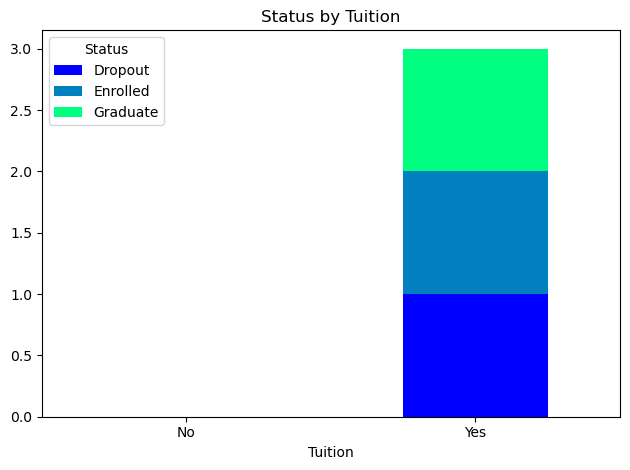

In [26]:
status_by_tuition_fees_up_to_date.plot(kind="bar", stacked=True, colormap='winter')
plt.title("Status by Tuition")
plt.xticks(rotation=0)
plt.xlabel("Tuition")
plt.tight_layout()
plt.show()

status akademik mahasiswa berdasarkan status pembayaran biaya kuliah (_Tuition Fees Up To Date_). Terlihat bahwa seluruh data yang tercatat hanya berasal dari mahasiswa dengan status pembayaran "Yes" (telah membayar), yaitu masing-masing **1** mahasiswa pada kategori dropout, enrolled, dan graduate. Sementara itu, tidak ada data untuk mahasiswa yang belum membayar biaya kuliah (kategori "No"). Karena distribusi datanya sangat kecil dan terbatas, belum dapat disimpulkan hubungan yang bermakna antara status pembayaran dan keberhasilan akademik. Diperlukan data tambahan untuk analisis yang lebih representatif dan reliabel.


#### Status by Gender


In [27]:
df['GenderCategory'] = df['Gender'].map({0: "Female", 1:"Male"})
status_by_gender = pd.pivot_table(
    df,
    values="Gender",
    index="GenderCategory",
    columns="Status",
    aggfunc="count"
)
status_by_gender

Status,Dropout,Enrolled,Graduate
GenderCategory,,,
Female,720,487,1661
Male,701,307,548


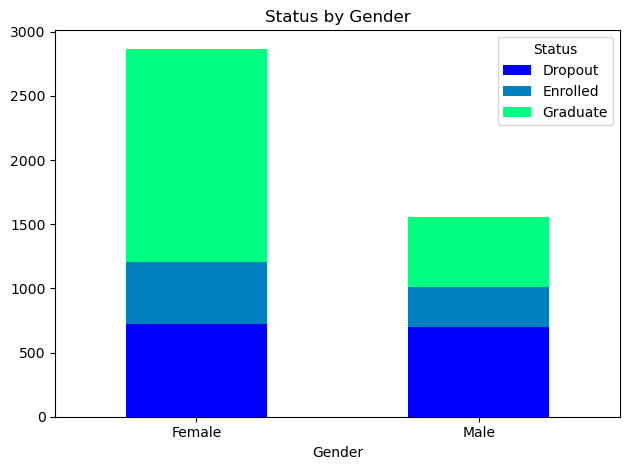

In [28]:
status_by_gender.plot(kind="bar", stacked=True, colormap='winter')
plt.title("Status by Gender")
plt.xticks(rotation=0)
plt.xlabel("Gender")
plt.tight_layout()
plt.show()

Status akademik mahasiswa berdasarkan gender. Mahasiswa perempuan memiliki angka kelulusan tertinggi yaitu **1.661**, dengan **487** masih aktif dan **720** mengalami dropout. Sebaliknya, mahasiswa laki-laki mencatat **548** lulusan, **307** masih aktif, dan **701** dropout. Meskipun jumlah dropout antara kedua kelompok relatif seimbang, perbedaan signifikan pada jumlah lulusan menunjukkan bahwa mahasiswa perempuan dalam dataset ini memiliki tingkat keberhasilan akademik yang lebih tinggi dibandingkan mahasiswa laki-laki.


In [29]:
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Inflation_rate,GDP,Status,MaritalStatusCategory,DaytimeEveningAttendance,DisplacedCategory,EducationalSpecialNeedsCategory,DebtorCategory,TuitionFeesUpToDateCategory,GenderCategory
0,1,17,5,171,1,1,122.0,1,19,12,...,1.4,1.74,Dropout,single,DayTime,Yes,No,No,Yes,Male
1,1,15,1,9254,1,1,160.0,1,1,3,...,-0.3,0.79,Graduate,single,DayTime,Yes,No,No,No,Male
2,1,1,5,9070,1,1,122.0,1,37,37,...,1.4,1.74,Dropout,single,DayTime,Yes,No,No,No,Male
3,1,17,2,9773,1,1,122.0,1,38,37,...,-0.8,-3.12,Graduate,single,DayTime,Yes,No,No,Yes,Female
4,2,39,1,8014,0,1,100.0,1,37,38,...,-0.3,0.79,Graduate,married,Evening,No,No,No,Yes,Female


#### Status by Scholarship holder


In [30]:
df['ScholarshipHolderCategory'] = df['Scholarship_holder'].map({0: "No", 1:"Yes"})
status_by_scholarship = pd.pivot_table(
    df,
    values="Scholarship_holder",
    index="ScholarshipHolderCategory",
    columns="Status",
    aggfunc="count"
)
status_by_scholarship

Status,Dropout,Enrolled,Graduate
ScholarshipHolderCategory,,,
No,1287,664,1374
Yes,134,130,835


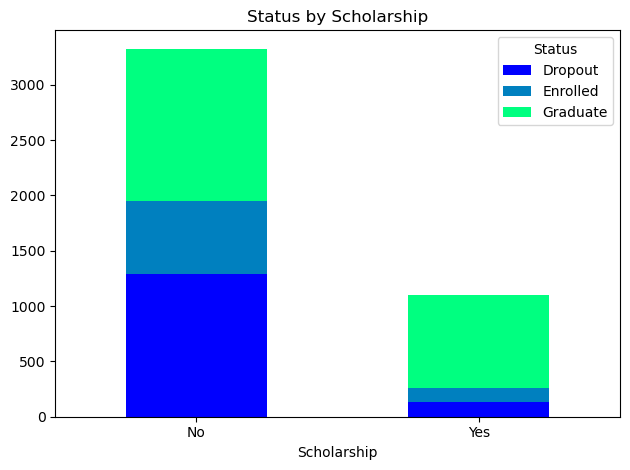

In [31]:
status_by_scholarship.plot(kind="bar", stacked=True, colormap='winter')
plt.title("Status by Scholarship")
plt.xticks(rotation=0)
plt.xlabel("Scholarship")
plt.tight_layout()
plt.show()

Status akademik mahasiswa berdasarkan status penerima beasiswa (_Scholarship Holder_). Mahasiswa yang menerima beasiswa memiliki jumlah lulusan sebanyak **835**, dengan **130** masih terdaftar dan **134** dropout. Sebaliknya, mahasiswa yang tidak menerima beasiswa menunjukkan angka dropout yang jauh lebih tinggi yaitu **1.287**, dengan **1.374** lulusan dan **664** masih aktif. Meskipun jumlah penerima beasiswa lebih sedikit, proporsi kelulusannya relatif tinggi, yang dapat mengindikasikan bahwa bantuan finansial melalui beasiswa berdampak positif terhadap retensi dan keberhasilan studi mahasiswa.


#### Status by Unemployment


In [32]:
status_by_unemplloyment_rate = pd.pivot_table(
    df,
    values="Unemployment_rate",
    index="Status",
    aggfunc="mean"
).round(2)

status_by_unemplloyment_rate

,Unemployment_rate
Status,
Dropout,11.62
Enrolled,11.27
Graduate,11.64


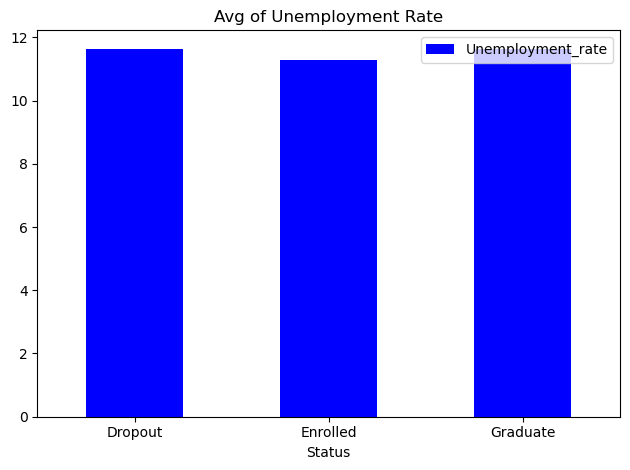

In [33]:
status_by_unemplloyment_rate.plot(kind="bar", colormap="winter")
plt.title("Avg of Unemployment Rate")
plt.xticks(rotation=0)
plt.xlabel("Status")
plt.tight_layout()
plt.show()

Rata-rata tingkat pengangguran wilayah asal mahasiswa berdasarkan status akademik mereka. Mahasiswa yang lulus berasal dari wilayah dengan tingkat pengangguran rata-rata tertinggi (**11.64%**), diikuti oleh mahasiswa yang dropout (**11.62%**), sedangkan mahasiswa yang masih aktif memiliki tingkat pengangguran wilayah terendah (**11.27%**). Perbedaannya relatif kecil, namun dapat memberikan indikasi awal bahwa **tingkat pengangguran di lingkungan sekitar tidak memiliki pengaruh yang kuat secara langsung terhadap keberhasilan akademik mahasiswa** dalam dataset ini.


#### Status by Inflation Rate


In [34]:
status_by_inflation_rate = pd.pivot_table(
    df,
    values="Inflation_rate",
    index="Status",
    aggfunc="mean"
).round(2)

status_by_inflation_rate

,Inflation_rate
Status,
Dropout,1.28
Enrolled,1.21
Graduate,1.20


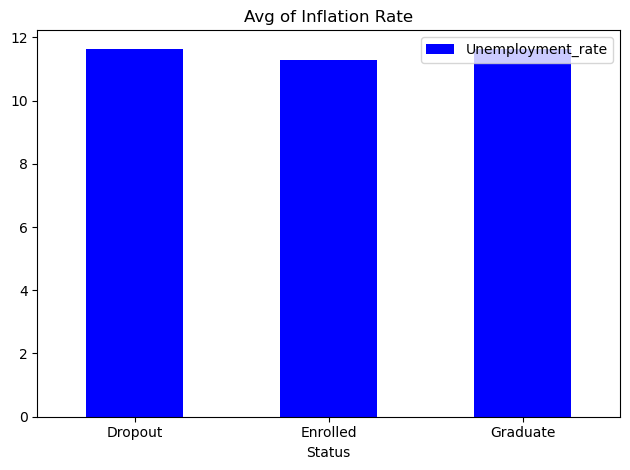

In [35]:
status_by_unemplloyment_rate.plot(kind="bar", colormap="winter")
plt.title("Avg of Inflation Rate")
plt.xticks(rotation=0)
plt.xlabel("Status")
plt.tight_layout()
plt.show()

Rata-rata tingkat inflasi (%) di wilayah asal mahasiswa berdasarkan status akademik mereka. Mahasiswa yang mengalami dropout berasal dari wilayah dengan tingkat inflasi rata-rata tertinggi (**1.28%**), diikuti oleh mahasiswa yang masih aktif (**1.21%**), dan lulusan memiliki tingkat inflasi wilayah terendah (**1.20%**). Perbedaan ini, meskipun kecil, dapat menunjukkan bahwa **tekanan ekonomi di tingkat regional seperti inflasi berpotensi memengaruhi keberlangsungan studi mahasiswa**, khususnya dalam hal risiko putus kuliah.


#### Status By GDP


In [36]:
status_by_gdp = pd.pivot_table(
    df,
    values="GDP",
    index="Status",
    aggfunc="mean"
).round(2)

status_by_gdp

,GDP
Status,
Dropout,-0.15
Enrolled,0.05
Graduate,0.08


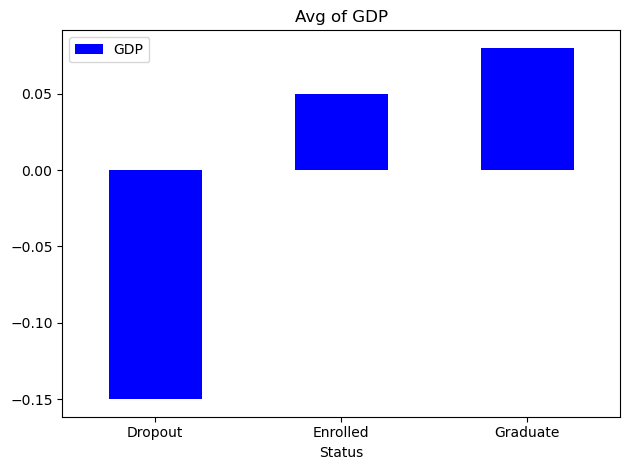

In [37]:
status_by_gdp.plot(kind="bar", colormap="winter")
plt.title("Avg of GDP")
plt.xticks(rotation=0)
plt.xlabel("Status")
plt.tight_layout()
plt.show()

Rata-rata nilai Produk Domestik Bruto (GDP) wilayah asal mahasiswa berdasarkan status akademik mereka. Mahasiswa yang lulus berasal dari wilayah dengan rata-rata pertumbuhan GDP tertinggi (**0.08**), diikuti oleh mahasiswa yang masih terdaftar (**0.05**), sedangkan mahasiswa yang mengalami dropout justru berasal dari wilayah dengan pertumbuhan GDP negatif (**-0.15**). Temuan ini mengindikasikan bahwa **kondisi ekonomi regional yang lebih baik (diukur melalui GDP) dapat berkontribusi positif terhadap keberhasilan akademik**, sedangkan wilayah dengan pertumbuhan ekonomi yang menurun cenderung memiliki proporsi dropout yang lebih tinggi.


In [38]:
# simpan ke file CSV untuk pembuatan Dashboard
dataset_dashboard_student = df.copy()
dataset_dashboard_student.to_csv("data/dataset_dashboard_student.csv", index=False)

## Modeling


## Evaluation
